<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [ ]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO_ROOT = Path('/content/latent-ability-ml')
    if not REPO_ROOT.exists():
        subprocess.check_call([
            'git',
            'clone',
            'https://github.com/manuelfjr/latent-ability-ml.git',
            str(REPO_ROOT),
        ])

    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        'numpy',
        'pandas',
        'matplotlib',
        'scipy',
        'scikit-learn',
        'seaborn',
        'joblib',
        'tqdm',
        'birt-gd',
    ])

    for candidate in [REPO_ROOT, REPO_ROOT / 'notebooks', REPO_ROOT / 'utils', REPO_ROOT / 'src']:
        candidate_str = str(candidate)
        if candidate_str not in sys.path:
            sys.path.insert(0, candidate_str)

    from nb_utils import set_root
    PROJECT_ROOT = REPO_ROOT
    print(f'Running in Colab with project root: {PROJECT_ROOT}')
else:
    from nb_utils import set_root
    PROJECT_ROOT = set_root(level=2)
    print(f'Running locally with project root: {PROJECT_ROOT}')


**Environment note.** Run the setup cell above first. It loads the repository and the local modules needed for this notebook, especially when opening it in Google Colab.


# Section 3: Beta4-IRT for Bounded Responses

This section connects the workshop to the two research papers. Beta4-IRT extends Beta3-IRT by separating the sign and magnitude of discrimination, and CLAIRE uses Beta4-IRT on an agreement-based response matrix to evaluate models.

The formal bridge matters. Before, Beta3-IRT defines the bounded response and its latent parameters as:

$$
p_{ij} \sim \mathcal{B}(\alpha_{ij}, \beta_{ij}),
$$

$$
\alpha_{ij} = \left(\frac{\theta_i}{\delta_j}\right)^{a_j},
\qquad
\beta_{ij} = \left(\frac{1-\theta_i}{1-\delta_j}\right)^{a_j},
$$

$$
\theta_i \sim \mathcal{B}(1,1),
\qquad
\delta_j \sim \mathcal{B}(1,1),
\qquad
a_j \sim \mathcal{N}(1,\sigma_0^2).
$$

With those definitions in place, the equation bellow writes the expected bounded response as:

$$
E[p_{ij} \mid \theta_i, \delta_j, a_j]
= \frac{\alpha_{ij}}{\alpha_{ij} + \beta_{ij}}
= \frac{1}{1 + \left(\frac{\delta_j}{1-\delta_j}\right)^{a_j}
\left(\frac{\theta_i}{1-\theta_i}\right)^{-a_j}}.
$$

Beta4 keeps the same bounded-response structure, but the equation bellow decomposes discrimination into a sign term $\tau_j$ and a magnitude term $\omega_j$:

$$
E[p_{ij} \mid \theta_i, \delta_j, \omega_j, \tau_j]
= \frac{1}{1 + \left(\frac{\delta_j}{1-\delta_j}\right)^{\tau_j \cdot \omega_j}
\left(\frac{\theta_i}{1-\theta_i}\right)^{-\tau_j \cdot \omega_j}}.
$$

So Beta4 can be read as a direct adaptation of Beta3 in which the effective discrimination is modeled in two parts instead of one.


## Paper-Aligned Message

The CLAIRE paper frames the key idea as follows:

- the **response matrix** is built from model agreement;
- **model ability** is high when a model agrees well on difficult items;
- **instance difficulty** is high when only the good models agree on that instance.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from birt import Beta4

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

from sklearn.metrics import (
    # external validation
    adjusted_rand_score,
    mutual_info_score,
    # internal validation
    silhouette_score,
    calinski_harabasz_score
)

from utils.transform import TransformPairwise
from utils.handson import (
    make_beta4_item_bank,
    plot_beta4_iccs,
)


## Step 1: Beta4-IRT item bank

In the Beta4 formulation, abilities and difficulties are bounded in `(0, 1)`, and discrimination is written as the product of a sign term and a magnitude term. In the notation above, the effective discrimination is $a_j = \tau_j \omega_j$.


In [3]:
beta4_bank_neg = make_beta4_item_bank(
    [
        {
            "item": "case_1",
            "difficulty": 0.15,
            "discrimination_sign": -0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_2",
            "difficulty": 0.50,
            "discrimination_sign": -0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_3",
            "difficulty": 0.82,
            "discrimination_sign": -0.5,
            "discrimination_magnitude": 5,
        },
    ]
)
beta4_bank_pos = make_beta4_item_bank(
    [
        {
            "item": "case_1",
            "difficulty": 0.15,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_2",
            "difficulty": 0.50,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 5,
        },
        {
            "item": "case_3",
            "difficulty": 0.82,
            "discrimination_sign": 0.5,
            "discrimination_magnitude": 5,
        },

    ]
)

beta4_bank = pd.concat([beta4_bank_neg, beta4_bank_pos], ignore_index=True)

In [4]:
beta4_bank

,item,difficulty,discrimination_sign,discrimination_magnitude,effective_discrimination
0,case_1,0.15,-0.5,5,-2.5
1,case_2,0.50,-0.5,5,-2.5
2,case_3,0.82,-0.5,5,-2.5
3,case_1,0.15,0.5,5,2.5
4,case_2,0.50,0.5,5,2.5
5,case_3,0.82,0.5,5,2.5


## Step 2: Show how Beta4 changes curve shapes

The paper emphasizes that Beta-family models can express richer shapes than the usual logistic ICCs. Here we keep the example small and visual.


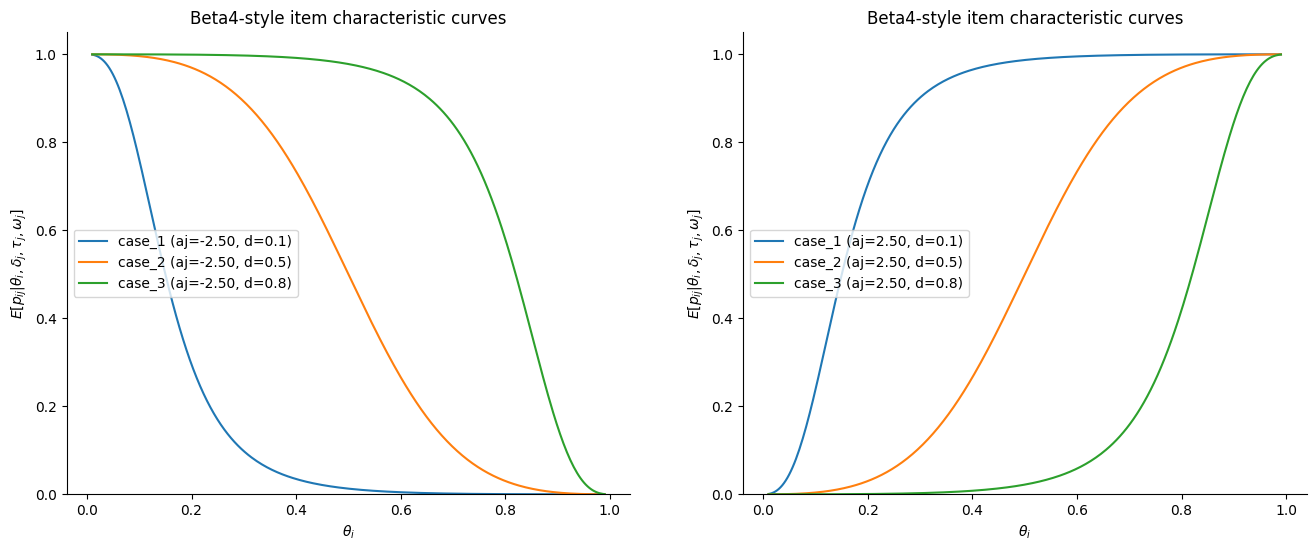

In [5]:
theta_grid = np.linspace(0.01, 0.99, 300)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
plot_beta4_iccs(
    beta4_bank_neg,
    theta=theta_grid,
    ax=ax[0]
)
plot_beta4_iccs(
    beta4_bank_pos,
    theta=theta_grid,
    ax=ax[1]
)
for _ax in ax:
    _ax.spines[["top", "right"]].set_visible(False)
plt.show()


In [6]:
# # difficulty, discrimination_sign, discrimination_magnitude, effective_discrimination
# fig, ax = plt.subplots(1, 1, figsize=(16, 8))
# ax = plot_beta4_family(
#     parameter_pairs=[
#         # (0.5, 0, 0, -2),
#         # (0.5, 0, 0, -1),
#         # (0.5, 0, 0, -0.5),
#         (0.5, 0.5, 6, None),
#         (0.5, 0.5, 4, None),
#         (0.5, 0.5, 2, None),
#     ],
#     theta=theta_grid,
#     ax=ax
# )
# plt.show()


## Step 3: Simulate Beta4 responses for a small model pool

This gives us a toy latent-ability setting.

### 3.1) Creating the dataset

In this step, it will be create the dataset based on each distribution for each parameter

$$
p_{ij} \sim \Beta(\alpha_{ij}, \beta_{ij}),
$$

$$
\alpha_{ij} = \bigg(\frac{\theta_i}{\delta_j}\bigg)^{aj}, \text{ } \beta_{ij} = \bigg(\frac{1 - \theta_i}{1 - \delta_j}\bigg)^{aj}, 
$$

$$
\theta_i \sim \Beta(1, 1), \text{ } \delta_j \sim \Beta(1, 1), \text{ } a_j \sim N(1, \sigma_{0}^{2})
$$

In [7]:
# setting some parameters to the toy dataset and the number of models 
sigma0 = 1
n_models = 10
n_instances = 300

In [8]:
thetai = np.random.beta(
    a=1,
    b=1,
    size=n_models
)
deltaj = np.random.beta(
    a=1,
    b=1,
    size=n_instances
)
aj = np.random.normal(
    loc=1,
    scale=sigma0,
    size=n_instances
)

In [9]:
alphaij, betaij, pij = (
    np.zeros((thetai.shape[0], deltaj.shape[0])),
    np.zeros((thetai.shape[0], deltaj.shape[0])),
    np.zeros((thetai.shape[0], deltaj.shape[0]))
)

In [10]:
for i in range(thetai.shape[0]):
    for j in range(deltaj.shape[0]):
        alphaij[i, j] = (thetai[i] / deltaj[j]) ** aj[j]
        betaij[i, j] = ((1 - thetai[i]) / (1 - deltaj[j])) ** aj[j]
        pij[i, j] = np.mean(
            np.random.beta(
                a = alphaij[i, j],
                b = betaij[i, j],
                size = 100
            )
        )
        
pij = pd.DataFrame(
    pij,
    index=[f'model_{i}' for i in range(n_models)],
    columns=[f'instance_{j}' for j in range(deltaj.shape[0])]
)

In [11]:
pij.shape

(10, 300)

### 3.2) Training the beta4

In this step, we will train the beta4 model. The parameters used are show in the code.

In [12]:
birt = Beta4(
    learning_rate=1, 
    epochs=10_000,
    n_respondents=pij.shape[0], 
    n_items=pij.shape[1],
    n_inits=1000,
    n_workers=1,
    random_seed=1,
    tol=10**(-8),
    set_priors=True
)
birt.fit(pij.T.values)

100%|██████████| 10000/10000 [00:21<00:00, 469.59it/s]


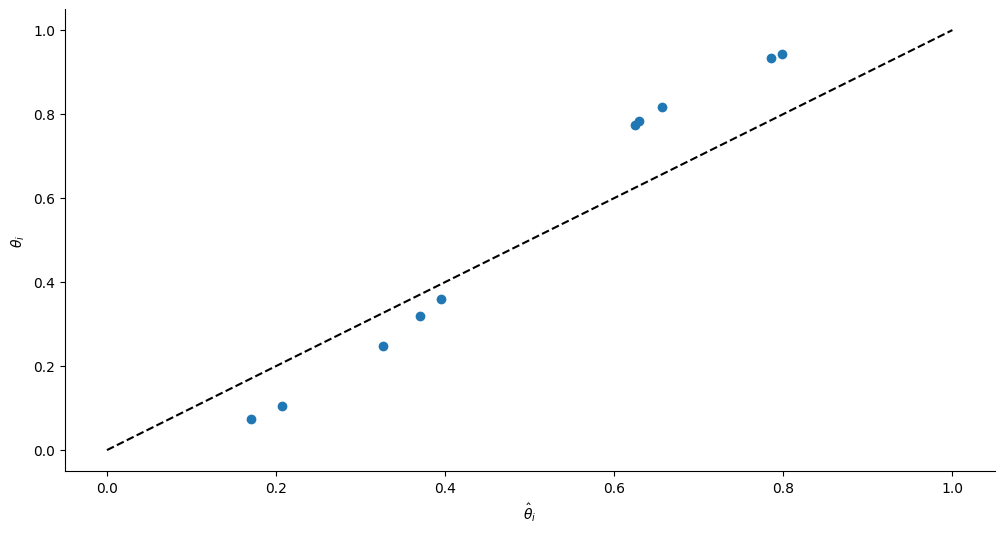

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(
    birt.abilities,
    thetai
)
ax.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$\hat{\theta}_i$")
ax.set_ylabel(r"$\theta_i$")
plt.show()

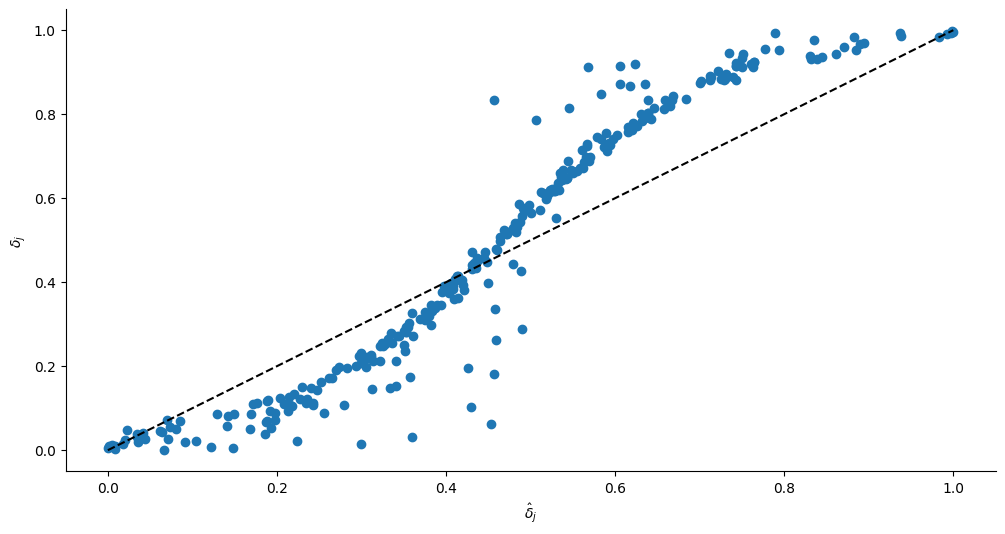

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(
    birt.difficulties,
    deltaj
)
ax.plot(
    [0, 1],
    [0, 1],
    color='black',
    linestyle='--'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$\hat{\delta}_j$")
ax.set_ylabel(r"$\delta_j$")
plt.show()

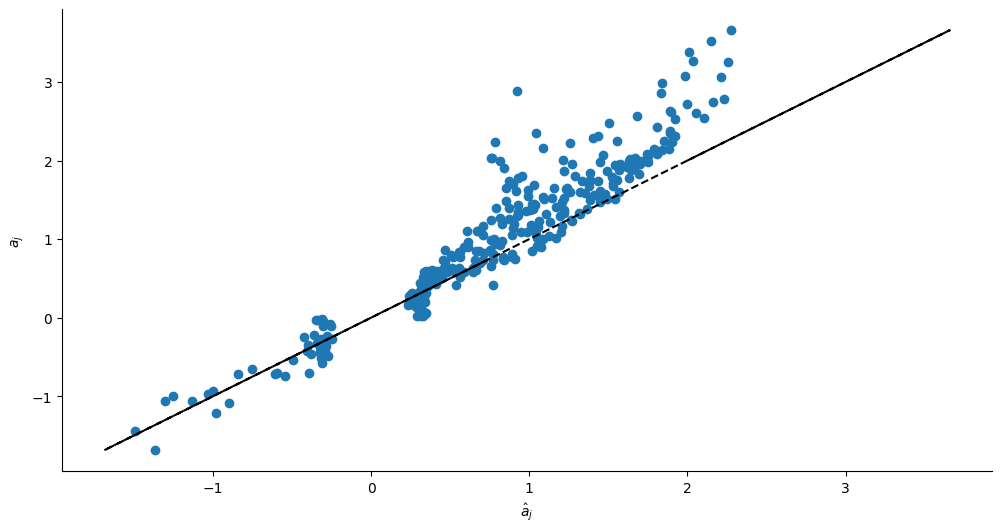

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(
    birt.discriminations,
    aj
)
ax.plot(
    aj,
    aj,
    color='black',
    linestyle='--'
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlabel(r"$\hat{a}_j$")
ax.set_ylabel(r"$a_j$")
plt.show()